# Compare metrics for Gardner's toroidal coordinates

In [ ]:
import os, sys

sys.path.append(".")
sys.path.append("../.")
from trajectory import World
from dreimac import CircularCoords # type: ignore
from toroidal_coordinates.compute_coord import *
from toroidal_coordinates.toroidal_lifting import *
import matplotlib.ticker as mticker
import matplotlib as mpl
from toroidal_coordinates.Gardner_toroidal import Gardner_persistence
from figures.plot_persistence_diagram import plot_persistence_diagram
import math
from trajectory import World, visualize_trajectory, random_walk
from pipelines import recover_traj_pipeline, compare_lifted_pipeline, plot_trajectory_comparison
from toroidal_coordinates.Gardner_toroidal import Gardner_coord

## Simulation


In [2]:
WORLD_SIZE = (100, 100)
HOLES = [(30, 30, 70, 70)]  # one square hole in the center
STEP_SIZE = 5
traj_length = 10000
world = World(WORLD_SIZE, holes=HOLES, step_size=STEP_SIZE)

processed_traj = np.load("/data/hyoon/GridDecode/revision_cache/trace_1.npy")
grid_activity = np.load("/data/hyoon/GridDecode/revision_cache/grid_activity_1.npy")

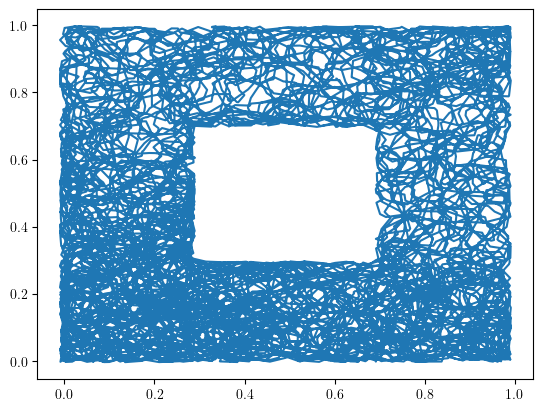

In [3]:
plt.plot(processed_traj[:, 0], processed_traj[:, 1])
plt.show()

In [4]:
# compute with DREIMAC, Euclidean (default)
tor_coord_dreimac, lifted_coord_dreimac = recover_traj_pipeline(grid_activity)
print(f"DREIMAC Toroidal coord shape: {tor_coord_dreimac.shape}")
print(f"DREIMACLifted coord shape:   {lifted_coord_dreimac.shape}")

tor_coord_gardner, lifted_coord_gardner = recover_traj_pipeline(grid_activity, method='gardner')
print(f"GARDNER Toroidal coord shape: {tor_coord_gardner.shape}")
print(f"GARDNER Lifted coord shape:   {lifted_coord_gardner.shape}")

DISTANCE_THRESHOLD: 4.240012859101196
DREIMAC Toroidal coord shape: (599999, 2)
DREIMACLifted coord shape:   (599999, 2)


/home/hyoon/GridCellDecoding/revision/.././toroidal_coordinates/Gardner_toroidal.py:150: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 4.262041652290201
GARDNER Toroidal coord shape: (599999, 2)
GARDNER Lifted coord shape:   (599999, 2)


In [ ]:
tor_coord_gardner_Euclidean, _,_,_, dgms_Euclidean = Gardner_coord(grid_activity.T, metric='euclidean', return_PD = True, save_path = "metric_lifting_comparison_results/Gardner_Euclidean_PD.npy")
lifted_coord_gardner_Euclidean = toroidal_lifting_distance_upgrade(tor_coord_gardner_Euclidean)

In [30]:
tor_coord_gardner_correlation, _,_,_, _ = Gardner_coord(smoothed.T, metric='correlation',
                                                     return_PD = True, save_path = "metric_lifting_comparison_results/Gardner_correlation_PD.npy")
lifted_coord_gardner_correlation = toroidal_lifting_distance_upgrade(tor_coord_gardner_correlation)


/home/hyoon/GridCellDecoding/revision/.././toroidal_coordinates/Gardner_toroidal.py:154: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 3.757069028828738


In [15]:
tor_coord_gardner_correlation, _,_,_, _ = Gardner_coord(grid_activity.T, metric='correlation',
                                                     return_PD = True, save_path = "metric_lifting_comparison_results/Gardner_correlation_PD.npy")
lifted_coord_gardner_correlation = toroidal_lifting_distance_upgrade(tor_coord_gardner_correlation)


/home/hyoon/GridCellDecoding/revision/.././toroidal_coordinates/Gardner_toroidal.py:154: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 4.038645784524555


In [17]:
processed_trace = processed_traj
lifted_coord_transformed_gardner_correlation, score_gardner_correlation = compare_lifted_pipeline(lifted_coord_gardner_correlation, processed_trace)

Error: 0.2695654108997631


In [7]:
processed_trace = processed_traj
lifted_coord_transformed_dreimac, score_dreimac = compare_lifted_pipeline(lifted_coord_dreimac, processed_trace)
lifted_coord_transformed_gardner, score_gardner = compare_lifted_pipeline(lifted_coord_gardner, processed_trace)
lifted_coord_transformed_gardner_Euclidean, score_gardner_Euclidean = compare_lifted_pipeline(lifted_coord_gardner_Euclidean, processed_trace)
lifted_coord_transformed_gardner_correlation, score_gardner_correlation = compare_lifted_pipeline(lifted_coord_gardner_correlation, processed_trace)

print("DREIMAC score:", score_dreimac)
print("GARDNER score:", score_gardner)
print("GARDNER (Euclidean) score:", score_gardner_Euclidean)
print("GARDNER (Correlation) score:", score_gardner_correlation)

Error: 0.018384554127408227
Error: 0.017723744544127385
Error: 0.017930821872233004
Error: 0.2695654108997631
DREIMAC score: 0.018384554127408227
GARDNER score: 0.017723744544127385
GARDNER (Euclidean) score: 0.017930821872233004
GARDNER (Correlation) score: 0.2695654108997631


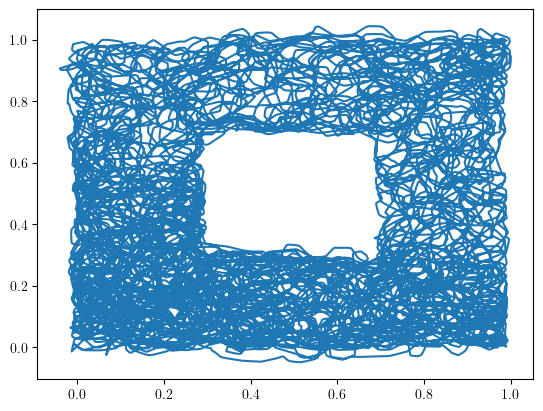

In [ ]:
plt.plot(lifted_coord_transformed_gardner_Euclidean[:, 0], lifted_coord_transformed_gardner_Euclidean[:, 1], label='GARDNER (Euclidean)')
plt.show()

In [8]:
DREIMAC_score = {}
Gardner_score = {}
Gardner_Euclidean_score = {}
Gardner_Correlation_score = {}

In [9]:
DREIMAC_score[1] = score_dreimac
Gardner_score[1] = score_gardner
Gardner_Euclidean_score[1] = score_gardner_Euclidean
Gardner_Correlation_score[1] = score_gardner_correlation

In [ ]:
import csv
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

CACHE_DIR = "/data/hyoon/GridDecode/revision_cache"
OUTPUT_CSV = os.path.join("revision", "metric_lifting_comparison_results", "per_trace_scores.csv")
N_WORKERS = min(5, os.cpu_count() or 1)


def compute_trace_scores(trace: int):
    """Compute all lifting scores for one trace and return a row dict."""
    processed_trace = np.load(os.path.join(CACHE_DIR, f"trace_{trace}.npy"))
    grid_activity = np.load(os.path.join(CACHE_DIR, f"grid_activity_{trace}.npy"))

    _, lifted_coord_dreimac = recover_traj_pipeline(grid_activity)
    _, lifted_coord_gardner = recover_traj_pipeline(grid_activity, method="gardner")

    tor_coord_gardner_euclidean, _, _, _ = Gardner_coord(grid_activity.T, metric="euclidean")
    lifted_coord_gardner_euclidean = toroidal_lifting_distance_upgrade(tor_coord_gardner_euclidean)

    tor_coord_gardner_correlation, _, _, _ = Gardner_coord(grid_activity.T, metric="correlation")
    lifted_coord_gardner_correlation = toroidal_lifting_distance_upgrade(tor_coord_gardner_correlation)

    _, score_dreimac = compare_lifted_pipeline(lifted_coord_dreimac, processed_trace)
    _, score_gardner = compare_lifted_pipeline(lifted_coord_gardner, processed_trace)
    _, score_gardner_euclidean = compare_lifted_pipeline(lifted_coord_gardner_euclidean, processed_trace)
    _, score_gardner_correlation = compare_lifted_pipeline(lifted_coord_gardner_correlation, processed_trace)

    return {
        "trace": trace,
        "dreimac_score": float(score_dreimac),
        "gardner_score": float(score_gardner),
        "gardner_euclidean_score": float(score_gardner_euclidean),
        "gardner_correlation_score": float(score_gardner_correlation),
    }


# Discover trace IDs from cache files so the cell scales automatically.
trace_ids = sorted(
    int(fname.split("_")[1].split(".")[0])
    for fname in os.listdir(CACHE_DIR)
    if fname.startswith("trace_") and fname.endswith(".npy")
)

rows = []
errors = []

with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    future_to_trace = {ex.submit(compute_trace_scores, trace): trace for trace in trace_ids}
    for future in as_completed(future_to_trace):
        trace = future_to_trace[future]
        try:
            row = future.result()
            rows.append(row)
            print(
                f"Trace {trace}: "
                f"DREIMAC={row['dreimac_score']:.6f}, "
                f"GARDNER={row['gardner_score']:.6f}, "
                f"EUCLIDEAN={row['gardner_euclidean_score']:.6f}, "
                f"CORRELATION={row['gardner_correlation_score']:.6f}"
            )
        except Exception as exc:
            errors.append((trace, str(exc)))
            print(f"Trace {trace} failed: {exc}")

rows.sort(key=lambda r: r["trace"])
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
with open(OUTPUT_CSV, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "trace",
            "dreimac_score",
            "gardner_score",
            "gardner_euclidean_score",
            "gardner_correlation_score",
        ],
    )
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved {len(rows)} trace score rows to {OUTPUT_CSV}")
if errors:
    print("Failed traces:", errors)

# Optional convenience dicts (matching your previous structure)
DREIMAC_score = {r["trace"]: r["dreimac_score"] for r in rows}
Gardner_score = {r["trace"]: r["gardner_score"] for r in rows}
Gardner_Euclidean_score = {r["trace"]: r["gardner_euclidean_score"] for r in rows}
Gardner_Correlation_score = {r["trace"]: r["gardner_correlation_score"] for r in rows}

/tmp/ipykernel_3719142/3826641100.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=20)


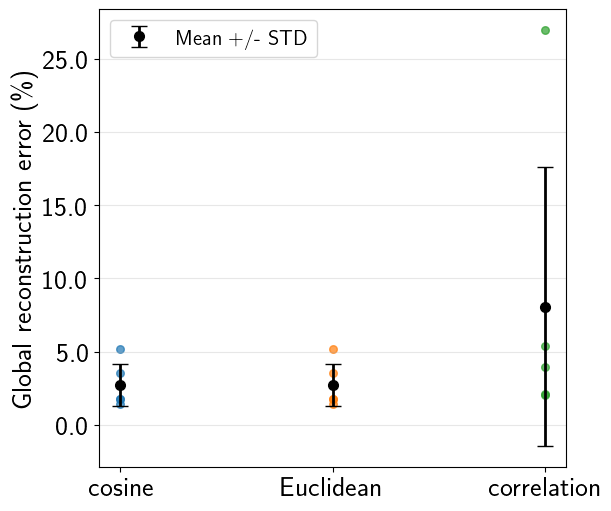

Loaded CSV: metric_lifting_comparison_results/per_trace_scores.csv
Method-wise mean +/- std (%):
      cosine: 2.7354 +/- 1.4314
   Euclidean: 2.7457 +/- 1.4301
 correlation: 8.0845 +/- 9.5164


In [40]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt

candidate_csv_paths = [
    "revision/metric_lifting_comparison_results/per_trace_scores.csv",
    "metric_lifting_comparison_results/per_trace_scores.csv",
    "/home/hyoon/GridCellDecoding/revision/metric_lifting_comparison_results/per_trace_scores.csv",
]

csv_path = next((p for p in candidate_csv_paths if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find per_trace_scores.csv. Checked:\n- "
        + "\n- ".join(candidate_csv_paths)
    )

rows = []
with open(csv_path, "r", newline="") as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append(
            {
                "trace": int(r["trace"]),
                "gardner": float(r["gardner_score"]),
                "gardner_euclidean": float(r["gardner_euclidean_score"]),
                "gardner_correlation": float(r["gardner_correlation_score"]),
            }
        )

rows = sorted(rows, key=lambda x: x["trace"])

method_keys = [
    "gardner",
    "gardner_euclidean",
    "gardner_correlation",
]
method_labels = ["cosine", "Euclidean", "correlation"]
score_dict = {
    "gardner": np.array([r["gardner"] for r in rows]) * 100,
    "gardner_euclidean": np.array([r["gardner_euclidean"] for r in rows]) * 100,
    "gardner_correlation": np.array([r["gardner_correlation"] for r in rows]) * 100,
}

means = np.array([score_dict[key].mean() for key in method_keys])
stds = np.array([score_dict[key].std() for key in method_keys])

x = np.arange(len(method_keys))
fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)

# Mean reconstruction error with STD whiskers.
ax.errorbar(
    x,
    means,
    yerr=stds,
    fmt="o",
    capsize=6,
    elinewidth=2,
    markersize=7,
    color="black",
    label="Mean +/- STD",
)

# Overlay per-trace points for context.
for i, key in enumerate(method_keys):
    ax.scatter(
        np.full_like(score_dict[key], i, dtype=float),
        score_dict[key],
        s=30,
        alpha=0.7,
    )

ax.set_xticks(x)
ax.set_xticklabels(method_labels, rotation=0, fontsize=20)
ax.set_yticklabels(ax.get_yticks(), fontsize=20)
ax.set_ylabel(r"Global reconstruction error (\%)", fontsize = 20)
#ax.set_title("Mismatch summary across traces (STD whiskers)")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize = 15)
plt.savefig("metric_lifting_comparison_results/Simulation_metric_comparisons_global.png")
plt.show()

print(f"Loaded CSV: {csv_path}")
print("Method-wise mean +/- std (%):")
for i, label in enumerate(method_labels):
    print(f"{label:>12}: {means[i]:.4f} +/- {stds[i]:.4f}")

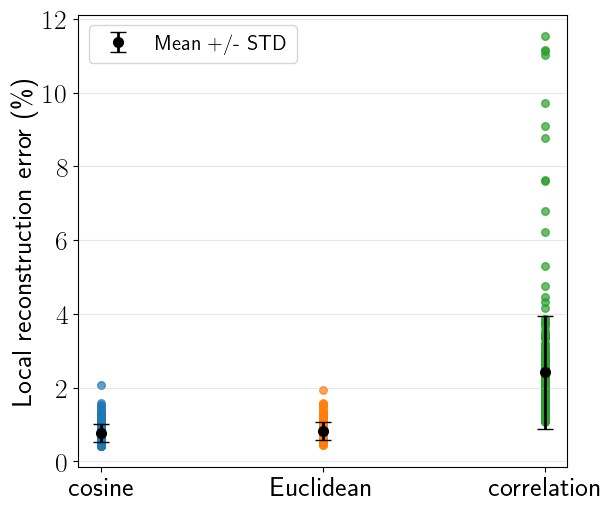

Loaded CSV: metric_lifting_comparison_results/per_trace_segment_scores.csv
Method-wise segment mean +/- std (%):
      cosine: 0.7651 +/- 0.2466
   Euclidean: 0.8173 +/- 0.2438
 correlation: 2.4154 +/- 1.5319


(array([0.7650738 , 0.81730346, 2.41537277]),
 array([0.24664974, 0.24378943, 1.5318571 ]))

In [41]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_segment_score_summary(segment_csv_path: str | None = None, show_points: bool = True):
    """Plot mean +/- std of segment scores across all traces for each Gardner method."""
    candidate_paths = [
        segment_csv_path,
        "revision/metric_lifting_comparison_results/per_trace_segment_scores.csv",
        "metric_lifting_comparison_results/per_trace_segment_scores.csv",
        "/home/hyoon/GridCellDecoding/revision/metric_lifting_comparison_results/per_trace_segment_scores.csv",
    ]
    candidate_paths = [p for p in candidate_paths if p is not None]

    resolved_csv = next((p for p in candidate_paths if os.path.exists(p)), None)
    if resolved_csv is None:
        raise FileNotFoundError(
            "Could not find per_trace_segment_scores.csv. Checked:\n- "
            + "\n- ".join(candidate_paths)
        )

    methods = ["gardner", "gardner_euclidean", "gardner_correlation"]
    labels = ["cosine", "Euclidean", "correlation"]
    scores = {m: [] for m in methods}

    with open(resolved_csv, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            method = row.get("method", "")
            if method in scores:
                # Convert to percentage for consistency with previous plot style.
                scores[method].append(float(row["segment_score"]) * 100.0)

    for method in methods:
        if len(scores[method]) == 0:
            raise ValueError(f"No segment rows found for method: {method}")
        scores[method] = np.array(scores[method], dtype=float)

    means = np.array([scores[m].mean() for m in methods])
    stds = np.array([scores[m].std() for m in methods])

    x = np.arange(len(methods))
    fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)

    ax.errorbar(
        x,
        means,
        yerr=stds,
        fmt="o",
        capsize=6,
        elinewidth=2,
        markersize=7,
        color="black",
        label="Mean +/- STD",
    )

    if show_points:
        for i, method in enumerate(methods):
            ax.scatter(
                np.full_like(scores[method], i, dtype=float),
                scores[method],
                s=30,
                alpha=0.7,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, fontsize=20)
    ax.tick_params(axis="y", labelsize=20)
    ax.set_ylabel(r"Local reconstruction error (\%)", fontsize=20)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=15)

    plt.savefig("metric_lifting_comparison_results/Simulation_metric_comparisons_segmental.png")
    plt.show()

    print(f"Loaded CSV: {resolved_csv}")
    print("Method-wise segment mean +/- std (%):")
    for i, label in enumerate(labels):
        print(f"{label:>12}: {means[i]:.4f} +/- {stds[i]:.4f}")

    return means, stds


# Example call
plot_segment_score_summary()

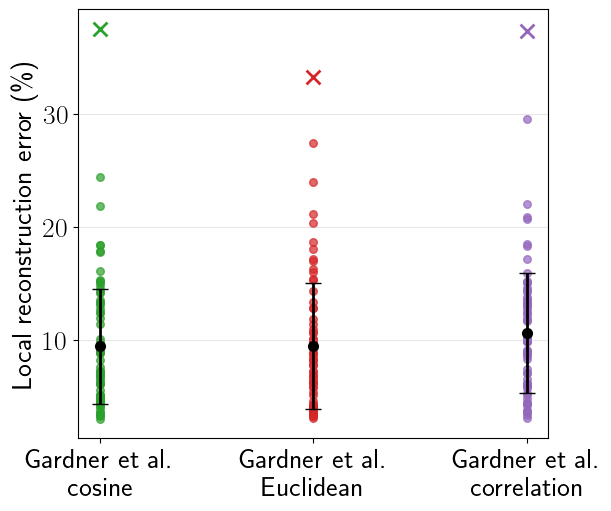

Loaded CSV: metric_lifting_comparison_results/lifting_metric_comparison_gardner_segment_scores.csv
Method-wise segment mean +/- std (%):
Gardner et al. 
 cosine: 9.4696 +/- 5.0898
Gardner et al. 
 Euclidean: 9.4620 +/- 5.5612
 Gardner et al. 
 correlation: 10.5974 +/- 5.2983


In [45]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt

csv_path = "metric_lifting_comparison_results/lifting_metric_comparison_gardner_segment_scores.csv"
csv_global = "metric_lifting_comparison_results/lifting_metric_comparison_gardner.csv"

methods =["cosine", "euclidean", "correlation"]
labels = ["Gardner et al. \n cosine", "Gardner et al. \n Euclidean", " Gardner et al. \n correlation"]
# Set custom colors: blue, orange, green
method_colors = {
    "cosine":"#2ca02c", # green
    "euclidean": "#d62728", # orange
    "correlation": "#9467bd", # purple
}

scores = {m: [] for m in methods}

# load segment errors
with open(csv_path, "r", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        method = row.get("metric", "")
        if method in scores:
            # Convert to percentage for consistency with previous plot style.
            scores[method].append(float(row["segment_score"]) * 100.0)

# load global errors
global_scores = {m: [] for m in methods}
with open(csv_global, "r", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        method = row.get("metric", "")
        if method in global_scores:
            global_scores[method].append(float(row["mismatch_score"]) * 100.0)

for method in methods:
    if len(scores[method]) == 0:
        raise ValueError(f"No segment rows found for method: {method}")
    scores[method] = np.array(scores[method], dtype=float)

means = np.array([scores[m].mean() for m in methods])
stds = np.array([scores[m].std() for m in methods])

x = np.arange(len(methods))
fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)

ax.errorbar(
    x,
    means,
    yerr=stds,
    fmt="o",
    capsize=6,
    elinewidth=2,
    markersize=7,
    color="black",
    label="Mean +/- STD",
)

for i, method in enumerate(methods):
    ax.scatter(
        np.full_like(scores[method], i, dtype=float),
        scores[method],
        s=30,
        alpha=0.7,
        color=method_colors[method],
        label=labels[i] if i == 0 else None,  # Only label first for legend
)
    ax.scatter(
        np.full_like(global_scores[method], i, dtype=float),
        global_scores[method],
        marker="x",
        s=100,
        color=method_colors[method],
        linewidths=2,
        label=None,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, fontsize=20)
ax.tick_params(axis="y", labelsize=20)
ax.set_ylabel(r"Local reconstruction error (\%)", fontsize=20)
ax.grid(axis="y", alpha=0.3)
#ax.legend(fontsize=15)

plt.savefig("metric_lifting_comparison_results/Gardner_metric_comparisons_segmental.png")
plt.show()

print(f"Loaded CSV: {csv_path}")
print("Method-wise segment mean +/- std (%):")
for i, label in enumerate(labels):
    print(f"{label:>12}: {means[i]:.4f} +/- {stds[i]:.4f}")



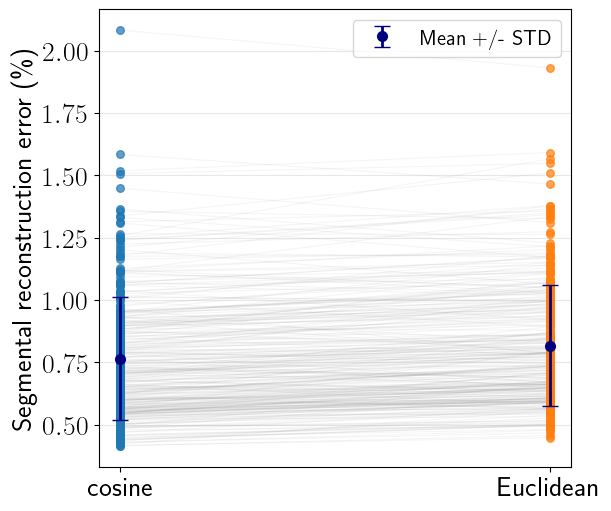

Loaded CSV: metric_lifting_comparison_results/per_trace_segment_scores.csv
Method-wise segment mean +/- std (%):
      cosine: 0.7651 +/- 0.2466
   Euclidean: 0.8173 +/- 0.2438
Connected pairs: 295


(array([0.7650738 , 0.81730346]), array([0.24664974, 0.24378943]))

In [ ]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_segment_score_summary_cosine_vs_euclidean(segment_csv_path: str | None = None, show_points: bool = True):
    """Plot mean +/- std of segment scores across traces for cosine vs Euclidean."""
    candidate_paths = [
        segment_csv_path,
        "revision/metric_lifting_comparison_results/per_trace_segment_scores.csv",
        "metric_lifting_comparison_results/per_trace_segment_scores.csv",
        "/home/hyoon/GridCellDecoding/revision/metric_lifting_comparison_results/per_trace_segment_scores.csv",
    ]
    candidate_paths = [p for p in candidate_paths if p is not None]

    resolved_csv = next((p for p in candidate_paths if os.path.exists(p)), None)
    if resolved_csv is None:
        raise FileNotFoundError(
            "Could not find per_trace_segment_scores.csv. Checked:\n- "
            + "\n- ".join(candidate_paths)
        )

    methods = ["gardner", "gardner_euclidean"]
    labels = ["cosine", "Euclidean"]
    scores = {m: [] for m in methods}
    pair_scores = {m: {} for m in methods}  # key: (trace, segment_index)

    with open(resolved_csv, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            method = row.get("method", "")
            if method in scores:
                score = float(row["segment_score"]) * 100.0
                scores[method].append(score)
                key = (int(row["trace"]), int(row["segment_index"]))
                pair_scores[method][key] = score

    for method in methods:
        if len(scores[method]) == 0:
            raise ValueError(f"No segment rows found for method: {method}")
        scores[method] = np.array(scores[method], dtype=float)

    means = np.array([scores[m].mean() for m in methods])
    stds = np.array([scores[m].std() for m in methods])

    x = np.arange(len(methods))
    fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)

    ax.errorbar(
        x,
        means,
        yerr=stds,
        fmt="o",
        capsize=6,
        elinewidth=2,
        markersize=7,
        color="navy",
        label="Mean +/- STD",
        zorder=3,
    )

    if show_points:
        # Draw faint lines connecting the same (trace, segment_index) pair.
        common_keys = sorted(set(pair_scores[methods[0]]) & set(pair_scores[methods[1]]))
        for key in common_keys:
            y0 = pair_scores[methods[0]][key]
            y1 = pair_scores[methods[1]][key]
            ax.plot([x[0], x[1]], [y0, y1], color="gray", alpha=0.08, linewidth=0.8, zorder=1)

        for i, method in enumerate(methods):
            ax.scatter(
                np.full_like(scores[method], i, dtype=float),
                scores[method],
                s=30,
                alpha=0.7,
                zorder=2,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, fontsize=20)
    ax.tick_params(axis="y", labelsize=20)
    ax.set_ylabel(r"Segmental reconstruction error (\%)", fontsize=20)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=15)

    plt.savefig("metric_lifting_comparison_results/Simulation_metric_comparisons_segmental_cosine_vs_euclidean.png")
    plt.show()

    print(f"Loaded CSV: {resolved_csv}")
    print("Method-wise segment mean +/- std (%):")
    for i, label in enumerate(labels):
        print(f"{label:>12}: {means[i]:.4f} +/- {stds[i]:.4f}")
    print(f"Connected pairs: {len(common_keys)}")

    return means, stds


plot_segment_score_summary_cosine_vs_euclidean()

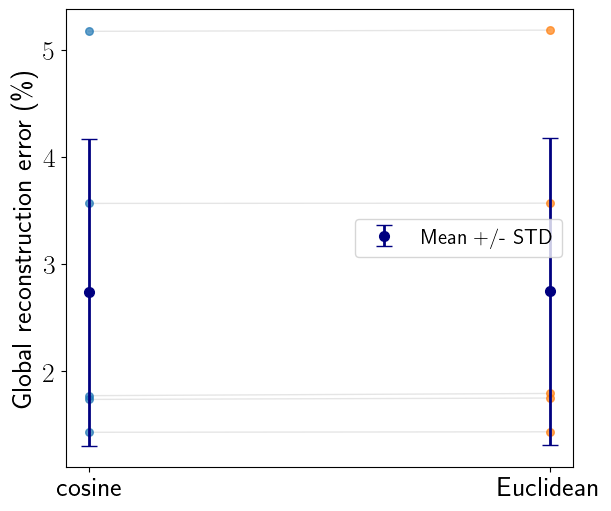

Loaded CSV: metric_lifting_comparison_results/per_trace_scores.csv
Method-wise global mean +/- std (%):
      cosine: 2.7354 +/- 1.4314
   Euclidean: 2.7457 +/- 1.4301
Connected traces: 5


(array([2.73538073, 2.74567178]), array([1.43137071, 1.43011721]))

In [38]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_global_score_summary_cosine_vs_euclidean(
    global_csv_path: str | None = None,
    show_points: bool = True,
):
    """Plot mean +/- std of global scores across traces for cosine vs Euclidean."""
    candidate_paths = [
        global_csv_path,
        "revision/metric_lifting_comparison_results/per_trace_scores.csv",
        "metric_lifting_comparison_results/per_trace_scores.csv",
        "/home/hyoon/GridCellDecoding/revision/metric_lifting_comparison_results/per_trace_scores.csv",
    ]
    candidate_paths = [p for p in candidate_paths if p is not None]

    resolved_csv = next((p for p in candidate_paths if os.path.exists(p)), None)
    if resolved_csv is None:
        raise FileNotFoundError(
            "Could not find per_trace_scores.csv. Checked:\n- "
            + "\n- ".join(candidate_paths)
        )

    methods = ["gardner", "gardner_euclidean"]
    labels = ["cosine", "Euclidean"]
    scores = {m: [] for m in methods}
    pair_scores = {m: {} for m in methods}  # key: trace

    with open(resolved_csv, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            trace = int(row["trace"])
            v_cos = float(row["gardner_score"]) * 100.0
            v_euc = float(row["gardner_euclidean_score"]) * 100.0
            scores["gardner"].append(v_cos)
            scores["gardner_euclidean"].append(v_euc)
            pair_scores["gardner"][trace] = v_cos
            pair_scores["gardner_euclidean"][trace] = v_euc

    for method in methods:
        if len(scores[method]) == 0:
            raise ValueError(f"No rows found for method: {method}")
        scores[method] = np.array(scores[method], dtype=float)

    means = np.array([scores[m].mean() for m in methods])
    stds = np.array([scores[m].std() for m in methods])

    x = np.arange(len(methods))
    fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)

    ax.errorbar(
        x,
        means,
        yerr=stds,
        fmt="o",
        capsize=6,
        elinewidth=2,
        markersize=7,
        color="navy",
        label="Mean +/- STD",
        zorder=3,
    )

    connected_traces = 0
    if show_points:
        common_traces = sorted(set(pair_scores[methods[0]]) & set(pair_scores[methods[1]]))
        for trace in common_traces:
            y0 = pair_scores[methods[0]][trace]
            y1 = pair_scores[methods[1]][trace]
            ax.plot([x[0], x[1]], [y0, y1], color="gray", alpha=0.2, linewidth=1.0, zorder=1)
            connected_traces += 1

        for i, method in enumerate(methods):
            ax.scatter(
                np.full_like(scores[method], i, dtype=float),
                scores[method],
                s=30,
                alpha=0.7,
                zorder=2,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, fontsize=20)
    ax.tick_params(axis="y", labelsize=20)
    ax.set_ylabel(r"Global reconstruction error (\%)", fontsize=20)
    ax.legend(fontsize=15)

    plt.savefig("metric_lifting_comparison_results/Gardner_metric_comparisons_global_cosine_vs_euclidean.png")
    plt.show()

    print(f"Loaded CSV: {resolved_csv}")
    print("Method-wise global mean +/- std (%):")
    for i, label in enumerate(labels):
        print(f"{label:>12}: {means[i]:.4f} +/- {stds[i]:.4f}")
    print(f"Connected traces: {connected_traces}")

    return means, stds


plot_global_score_summary_cosine_vs_euclidean()

## Plot for simualted data, toroidal coordinates obtained from Gardner et al vs DREIMAC

In [ ]:
DIR = "/data/hyoon/GridDecode/grid_fields/"
TRIALS = [0, 1, 2, 3, 4]

dreimac_cosine = {}   # n -> {"lifted_coord": ..., "score": ...}
dreimac_lifting = {}  # n -> {"lifted_coord": ..., "score": ...}

for n in TRIALS:
    cosine_file = os.path.join(DIR, f"random_walk_1holes_25000_n{n}_dreimac_cosine_lifting_results.npz")
    lifting_file = os.path.join(DIR, f"random_walk_1holes_25000_n{n}_dreimac_lifting_results.npz")

    d = np.load(cosine_file)
    dreimac_cosine[n] = {"lifted_coord": d["lifted_coord_dreimac"], "score": float(d["score_dreimac"])}

    d = np.load(lifting_file)
    dreimac_lifting[n] = {"lifted_coord": d["lifted_coord_dreimac"], "score": float(d["score_dreimac"])}

print(f"{'n':>3}  {'cosine score':>14}  {'dreimac score':>14}")
for n in TRIALS:
    print(f"{n:>3}  {dreimac_cosine[n]['score']:>14.6f}  {dreimac_lifting[n]['score']:>14.6f}")

d.keys(): KeysView(NpzFile '/data/hyoon/GridDecode/grid_fields/random_walk_1holes_25000_n0_dreimac_cosine_lifting_results.npz' with keys: lifted_coord_dreimac, score_dreimac)
d.keys(): KeysView(NpzFile '/data/hyoon/GridDecode/grid_fields/random_walk_1holes_25000_n1_dreimac_cosine_lifting_results.npz' with keys: lifted_coord_dreimac, score_dreimac)
d.keys(): KeysView(NpzFile '/data/hyoon/GridDecode/grid_fields/random_walk_1holes_25000_n2_dreimac_cosine_lifting_results.npz' with keys: lifted_coord_dreimac, score_dreimac)
d.keys(): KeysView(NpzFile '/data/hyoon/GridDecode/grid_fields/random_walk_1holes_25000_n3_dreimac_cosine_lifting_results.npz' with keys: lifted_coord_dreimac, score_dreimac)
d.keys(): KeysView(NpzFile '/data/hyoon/GridDecode/grid_fields/random_walk_1holes_25000_n4_dreimac_cosine_lifting_results.npz' with keys: lifted_coord_dreimac, score_dreimac)
  n    cosine score   dreimac score
  0        0.026521        0.024654
  1        0.020142        0.021276
  2        0.0147

In [29]:
from pipelines import segmental_compare_pipeline

DIR = "/data/hyoon/GridDecode/grid_fields/"
TRIALS = [0, 1, 2, 3, 4]
SEG_LEN = 10000


def compute_dreimac_cosine_segment_scores(trials=TRIALS, seg_len=SEG_LEN, grid_fields_dir=DIR):
    """
    For each trial n, loads lifted_coord_dreimac_n.npy and the matching processed_trace,
    aligns lifted to trace via compare_lifted_pipeline, then computes per-segment mismatch scores.

    Returns:
        global_scores : dict  n -> float
        segment_scores: dict  n -> list[float]
    """
    global_scores = {}
    segment_scores = {}

    for n in trials:
        # load trace
        npz = np.load(os.path.join(grid_fields_dir, f"random_walk_1holes_25000_n{n}_grid_activity.npz"))
        processed_trace = npz["processed_trace"]

        # load lifted coords (DREIMAC, cosine)
        cosine_file = os.path.join(DIR, f"random_walk_1holes_25000_n{n}_dreimac_cosine_lifting_results.npz")
        d = np.load(cosine_file)
        lifted_coord = d["lifted_coord_dreimac"]

        lifted_transformed, global_score = compare_lifted_pipeline(lifted_coord, processed_trace)
        seg_scores = segmental_compare_pipeline(lifted_transformed, processed_trace, seg_len)

        global_scores[n] = global_score
        segment_scores[n] = seg_scores
        print(f"n={n}: global={global_score:.6f}, n_segments={len(seg_scores)}")

    return global_scores, segment_scores


global_scores_dreimac_cosine, segment_scores_dreimac_cosine = compute_dreimac_cosine_segment_scores()

Mismatch score: 0.026520936421874333
Segmental mismatch scores: mean=0.012217, std=0.003118
n=0: global=0.026521, n_segments=59
Mismatch score: 0.020141625024841722
Segmental mismatch scores: mean=0.012244, std=0.003181
n=1: global=0.020142, n_segments=59
Mismatch score: 0.014792846932539547
Segmental mismatch scores: mean=0.011740, std=0.003129
n=2: global=0.014793, n_segments=59
Mismatch score: 0.017427290831916308
Segmental mismatch scores: mean=0.012958, std=0.003424
n=3: global=0.017427, n_segments=59
Mismatch score: 0.017728619507265626
Segmental mismatch scores: mean=0.012816, std=0.003255
n=4: global=0.017729, n_segments=59


In [33]:
def compute_dreimac_euclidean_segment_scores(trials=TRIALS, seg_len=SEG_LEN, grid_fields_dir=DIR):
    """
    For each trial n, loads lifted_coord_dreimac_n.npy and the matching processed_trace,
    aligns lifted to trace via compare_lifted_pipeline, then computes per-segment mismatch scores.

    Returns:
        global_scores : dict  n -> float
        segment_scores: dict  n -> list[float]
    """
    global_scores = {}
    segment_scores = {}

    for n in trials:
        # load trace
        npz = np.load(os.path.join(grid_fields_dir, f"random_walk_1holes_25000_n{n}_grid_activity.npz"))
        processed_trace = npz["processed_trace"]

        # load lifted coords (DREIMAC, Euclidean)
        dreimac_file = os.path.join(DIR, f"random_walk_1holes_25000_n{n}_dreimac_lifting_results.npz")
        d = np.load(dreimac_file)
        lifted_coord = d["lifted_coord_dreimac"]

        lifted_transformed, global_score = compare_lifted_pipeline(lifted_coord, processed_trace)
        seg_scores = segmental_compare_pipeline(lifted_transformed, processed_trace, seg_len)

        global_scores[n] = global_score
        segment_scores[n] = seg_scores
        print(f"n={n}: global={global_score:.6f}, n_segments={len(seg_scores)}")

    return global_scores, segment_scores


global_scores_dreimac_euclidean, segment_scores_dreimac_euclidean = compute_dreimac_euclidean_segment_scores()

Mismatch score: 0.024654197845344016
Segmental mismatch scores: mean=0.012856, std=0.003042
n=0: global=0.024654, n_segments=59
Mismatch score: 0.021276260907630358
Segmental mismatch scores: mean=0.011623, std=0.002988
n=1: global=0.021276, n_segments=59
Mismatch score: 0.01297502373723197
Segmental mismatch scores: mean=0.011879, std=0.003265
n=2: global=0.012975, n_segments=59
Mismatch score: 0.017599408871721147
Segmental mismatch scores: mean=0.012000, std=0.003128
n=3: global=0.017599, n_segments=59
Mismatch score: 0.024211296340051345
Segmental mismatch scores: mean=0.011326, std=0.002929
n=4: global=0.024211, n_segments=59


In [35]:
def compute_Gardner_cosine_segment_scores(trials=TRIALS, seg_len=SEG_LEN, grid_fields_dir=DIR):
    """
    For each trial n, loads lifted_coord_gardner_n.npy and the matching processed_trace,
    aligns lifted to trace via compare_lifted_pipeline, then computes per-segment mismatch scores.

    Returns:
        global_scores : dict  n -> float
        segment_scores: dict  n -> list[float]
    """
    global_scores = {}
    segment_scores = {}

    for n in trials:
        # load trace
        npz = np.load(os.path.join(grid_fields_dir, f"random_walk_1holes_25000_n{n}_grid_activity.npz"))
        processed_trace = npz["processed_trace"]

        # load lifted coords (Gardner, Cosine)
        gardner_file = os.path.join(DIR, f"random_walk_1holes_25000_n{n}_lifting_results.npz")
        d = np.load(gardner_file)
        lifted_coord = d["lifted_coord_gardner"]

        lifted_transformed, global_score = compare_lifted_pipeline(lifted_coord, processed_trace)
        seg_scores = segmental_compare_pipeline(lifted_transformed, processed_trace, seg_len)

        global_scores[n] = global_score
        segment_scores[n] = seg_scores
        print(f"n={n}: global={global_score:.6f}, n_segments={len(seg_scores)}")

    return global_scores, segment_scores


global_scores_Gardner_cosine, segment_scores_Gardner_cosine = compute_Gardner_cosine_segment_scores()

Mismatch score: 0.026898222156891964
Segmental mismatch scores: mean=0.008183, std=0.002176
n=0: global=0.026898, n_segments=59
Mismatch score: 0.01950669972497796
Segmental mismatch scores: mean=0.008422, std=0.002185
n=1: global=0.019507, n_segments=59
Mismatch score: 0.01075955828034053
Segmental mismatch scores: mean=0.010384, std=0.002581
n=2: global=0.010760, n_segments=59
Mismatch score: 0.010830041409639139
Segmental mismatch scores: mean=0.010522, std=0.002654
n=3: global=0.010830, n_segments=59
Mismatch score: 0.02453430283861753
Segmental mismatch scores: mean=0.009202, std=0.002496
n=4: global=0.024534, n_segments=59


In [31]:
def compute_Gardner_Euclidean_segment_scores(trials=TRIALS, seg_len=SEG_LEN, grid_fields_dir=DIR):
    """
    For each trial n, loads lifted_coord_gardner_euclidean_n.npy and the matching processed_trace,
    aligns lifted to trace via compare_lifted_pipeline, then computes per-segment mismatch scores.

    Returns:
        global_scores : dict  n -> float
        segment_scores: dict  n -> list[float]
    """
    global_scores = {}
    segment_scores = {}

    for n in trials:
        npz = np.load(os.path.join(grid_fields_dir, f"random_walk_1holes_25000_n{n}_grid_activity.npz"))
        processed_trace = npz["processed_trace"]

        lifted_coord = np.load(os.path.join(grid_fields_dir, f"lifted_coord_gardner_euclidean_{n}.npy"))

        lifted_transformed, global_score = compare_lifted_pipeline(lifted_coord, processed_trace)
        seg_scores = segmental_compare_pipeline(lifted_transformed, processed_trace, seg_len)

        global_scores[n] = global_score
        segment_scores[n] = seg_scores
        print(f"n={n}: global={global_score:.6f}, n_segments={len(seg_scores)}")

    return global_scores, segment_scores


global_scores_Gardner_euclidean, segment_scores_Gardner_euclidean = compute_Gardner_Euclidean_segment_scores()

Mismatch score: 0.02619974912478658
Segmental mismatch scores: mean=0.009451, std=0.002381
n=0: global=0.026200, n_segments=59
Mismatch score: 0.019697245229369467
Segmental mismatch scores: mean=0.009296, std=0.002470
n=1: global=0.019697, n_segments=59
Mismatch score: 0.015290991442624396
Segmental mismatch scores: mean=0.013006, std=0.003910
n=2: global=0.015291, n_segments=59
Mismatch score: 0.016983852932735008
Segmental mismatch scores: mean=0.010607, std=0.002707
n=3: global=0.016984, n_segments=59
Mismatch score: 0.01730935159074735
Segmental mismatch scores: mean=0.010659, std=0.002649
n=4: global=0.017309, n_segments=59


In [32]:
def compute_Gardner_correlation_segment_scores(trials=TRIALS, seg_len=SEG_LEN, grid_fields_dir=DIR):
    global_scores = {}
    segment_scores = {}
    for n in trials:
        npz = np.load(os.path.join(grid_fields_dir, f"random_walk_1holes_25000_n{n}_grid_activity.npz"))
        processed_trace = npz["processed_trace"]
        lifted_coord = np.load(os.path.join(grid_fields_dir, f"lifted_coord_gardner_correlation_{n}.npy"))
        lifted_transformed, global_score = compare_lifted_pipeline(lifted_coord, processed_trace)
        seg_scores = segmental_compare_pipeline(lifted_transformed, processed_trace, seg_len)
        global_scores[n] = global_score
        segment_scores[n] = seg_scores
        print(f"n={n}: global={global_score:.6f}, n_segments={len(seg_scores)}")
    return global_scores, segment_scores

global_scores_Gardner_correlation, segment_scores_Gardner_correlation = compute_Gardner_correlation_segment_scores()

Mismatch score: 0.23446806904058926
Segmental mismatch scores: mean=0.132082, std=0.051326
n=0: global=0.234468, n_segments=59
Mismatch score: 0.026041288192253008
Segmental mismatch scores: mean=0.030992, std=0.010773
n=1: global=0.026041, n_segments=59
Mismatch score: 0.0183595107064936
Segmental mismatch scores: mean=0.021215, std=0.006021
n=2: global=0.018360, n_segments=59
Mismatch score: 0.019920780386463017
Segmental mismatch scores: mean=0.021104, std=0.005462
n=3: global=0.019921, n_segments=59
Mismatch score: 0.021523578264334237
Segmental mismatch scores: mean=0.023750, std=0.005499
n=4: global=0.021524, n_segments=59


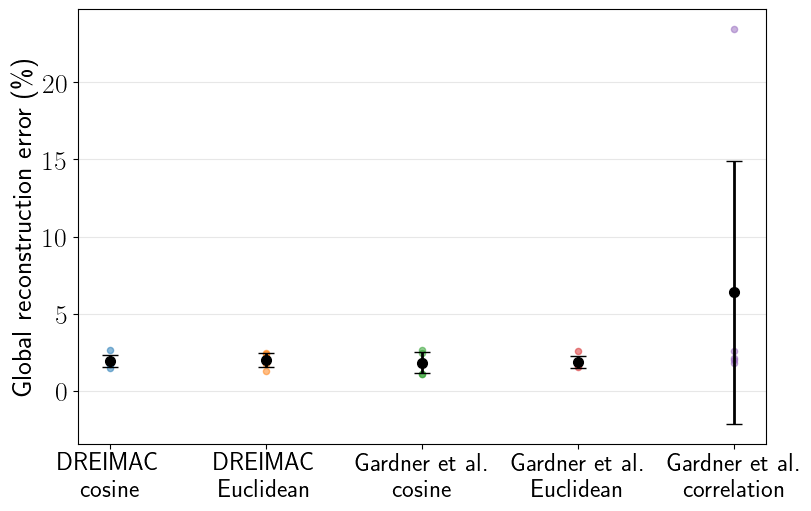

Saved: metric_lifting_comparison_results/all_methods_global_mismatch_simulaiton.png


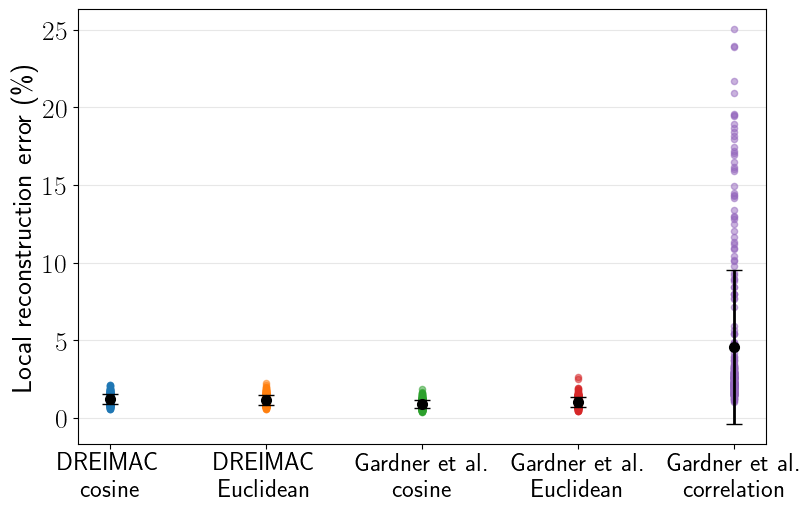

Saved: metric_lifting_comparison_results/all_methods_segmental_mismatch_simulation.png


In [ ]:
# --- Setup ---
methods = [
    ("DREIMAC\ncosine",       global_scores_dreimac_cosine,      segment_scores_dreimac_cosine),
    ("DREIMAC\nEuclidean",    global_scores_dreimac_euclidean,   segment_scores_dreimac_euclidean),
    ("Gardner et al.\ncosine",       global_scores_Gardner_cosine,      segment_scores_Gardner_cosine),
    ("Gardner et al.\nEuclidean",    global_scores_Gardner_euclidean,   segment_scores_Gardner_euclidean),
    ("Gardner et al.\ncorrelation",  global_scores_Gardner_correlation, segment_scores_Gardner_correlation),
]

labels       = [m[0] for m in methods]
x            = np.arange(len(methods))
global_vals  = [np.array(list(m[1].values())) * 100 for m in methods]
segment_vals = [np.array([s for segs in m[2].values() for s in segs]) * 100 for m in methods]

def _plot_panel(means, stds, per_trial_vals, ylabel, save_path):
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    ax.errorbar(x, means, yerr=stds, fmt="o", capsize=6, elinewidth=2,
                markersize=7, color="black", label="Mean ± STD", zorder=3)
    for i, vals in enumerate(per_trial_vals):
        ax.scatter(np.full(len(vals), i), vals, s=20, alpha=0.5, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=18)
    ax.tick_params(axis="y", labelsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.grid(axis="y", alpha=0.3)
    #ax.legend(fontsize=12)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

# Global
global_means  = [v.mean() for v in global_vals]
global_stds   = [v.std()  for v in global_vals]
_plot_panel(global_means, global_stds, global_vals,
            "Global reconstruction error (\%)",
            "metric_lifting_comparison_results/all_methods_global_mismatch_simulaiton.png")

# Segmental
segment_means = [v.mean() for v in segment_vals]
segment_stds  = [v.std()  for v in segment_vals]
_plot_panel(segment_means, segment_stds, segment_vals,
            "Local reconstruction error (\%)",
            "metric_lifting_comparison_results/all_methods_segmental_mismatch_simulation.png")



In [46]:
print("\nGlobal mean ± std (%):")
for label, mean, std in zip(labels, global_means, global_stds):
    print(f"  {label.replace(chr(10), ' '):25s}: {mean:.4f} ± {std:.4f}")
print("\nSegmental mean ± std (%):")
for label, mean, std in zip(labels, segment_means, segment_stds):
    print(f"  {label.replace(chr(10), ' '):25s}: {mean:.4f} ± {std:.4f}")


Global mean ± std (%):
  Gardner et al.   cosine  : 1.9322 ± 0.3978
  Gardner et al.   Euclidean: 2.0143 ± 0.4383
   Gardner et al.   correlation: 1.8506 ± 0.6733

Segmental mean ± std (%):
  Gardner et al.   cosine  : 1.2395 ± 0.3253
  Gardner et al.   Euclidean: 1.1937 ± 0.3115
   Gardner et al.   correlation: 0.9342 ± 0.2613


In [47]:
dreimac_summary = {
    "DREIMAC cosine":     (global_scores_dreimac_cosine,    segment_scores_dreimac_cosine),
    "DREIMAC Euclidean":  (global_scores_dreimac_euclidean, segment_scores_dreimac_euclidean),
}

for name, (g_scores, s_scores) in dreimac_summary.items():
    g = np.array(list(g_scores.values())) * 100
    s = np.array([score for segs in s_scores.values() for score in segs]) * 100
    print(f"{name}")
    print(f"  Global:    {g.mean():.4f} ± {g.std():.4f} %")
    print(f"  Segmental: {s.mean():.4f} ± {s.std():.4f} %")

DREIMAC cosine
  Global:    1.9322 ± 0.3978 %
  Segmental: 1.2395 ± 0.3253 %
DREIMAC Euclidean
  Global:    2.0143 ± 0.4383 %
  Segmental: 1.1937 ± 0.3115 %


In [56]:
all_methods = {
    "DREIMAC cosine":      (global_scores_dreimac_cosine,      segment_scores_dreimac_cosine),
    "DREIMAC Euclidean":   (global_scores_dreimac_euclidean,   segment_scores_dreimac_euclidean),
    "Gardner cosine":      (global_scores_Gardner_cosine,      segment_scores_Gardner_cosine),
    "Gardner Euclidean":   (global_scores_Gardner_euclidean,   segment_scores_Gardner_euclidean),
    "Gardner correlation": (global_scores_Gardner_correlation, segment_scores_Gardner_correlation),
}

print(f"{'Method':<25} {'Global (mean ± std)':>22} {'Segmental (mean ± std)':>24}")
print("-" * 74)
for name, (g_scores, s_scores) in all_methods.items():
    g = np.array(list(g_scores.values())) * 100
    s = np.array([score for segs in s_scores.values() for score in segs]) * 100
    print(f"{name:<25} {g.mean():.4f} ± {g.std():.4f}         {s.mean():.4f} ± {s.std():.4f}")

Method                       Global (mean ± std)   Segmental (mean ± std)
--------------------------------------------------------------------------
DREIMAC cosine            1.9322 ± 0.3978         1.2395 ± 0.3253
DREIMAC Euclidean         2.0143 ± 0.4383         1.1937 ± 0.3115
Gardner cosine            1.8506 ± 0.6733         0.9342 ± 0.2613
Gardner Euclidean         1.9096 ± 0.3820         1.0604 ± 0.3169
Gardner correlation       6.4063 ± 8.5241         4.5829 ± 4.9419


In [57]:
import platform, psutil, os
print(platform.processor())
print(platform.machine())
print(platform.platform())
print(f"RAM: {psutil.virtual_memory().total / 1e9:.0f} GB")
print(f"CPU cores: {os.cpu_count()}")

x86_64
x86_64
Linux-4.18.0-477.21.1.el8_8.x86_64-x86_64-with-glibc2.28
RAM: 541 GB
CPU cores: 64


###  Plot the persistence diagrams using cosine vs correlation dissimialrity

In [ ]:

Gardner_cosine_persistence = Gardner_persistence(grid_activity.T, maxdim = 2)

/home/hyoon/GridCellDecoding/revision/.././toroidal_coordinates/Gardner_toroidal.py:74: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


(-3.349072265625, 38.01197021484375)

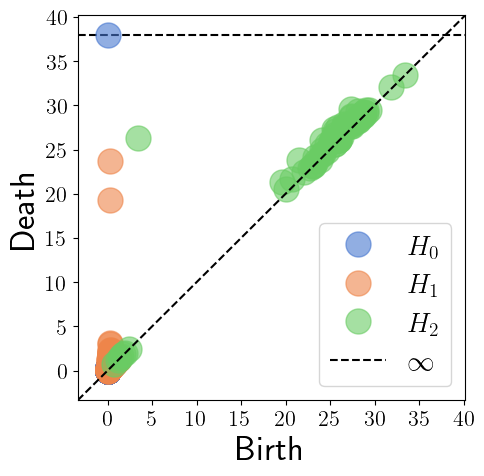

In [ ]:
plot_persistence_diagram(Gardner_cosine_persistence["dgms"]) #save_path = "metric_lifting_comparison_results/Gardner_cosine_PD.png")

In [ ]:

Gardner_correlation_persistence = Gardner_persistence(grid_activity.T, maxdim = 2, metric='correlation')

/home/hyoon/GridCellDecoding/revision/.././toroidal_coordinates/Gardner_toroidal.py:74: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


(-3.0070478439331056, 34.12999302864075)

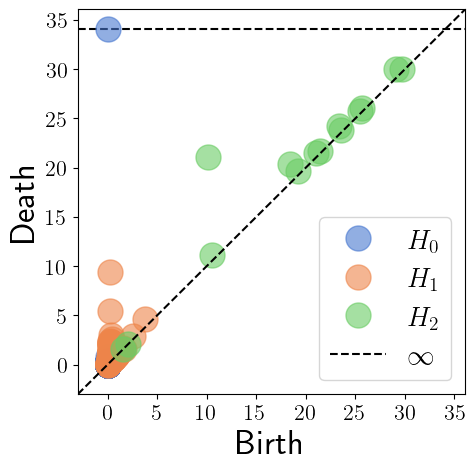

In [ ]:
plot_persistence_diagram(Gardner_correlation_persistence["dgms"]) 